# Tarea 3 Data Analysis y Machine Learning
### Joaquín Aravena

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import missingno as msno
from stepmix.stepmix import StepMix

%matplotlib inline

In [2]:
sns.set_palette("tab10")

In [3]:
df = pd.read_csv("junaeb3.csv")
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [4]:
#df.drop(axis=1,columns=["vive_madre","vive_padre"],inplace=True)
df = df.dropna(axis=0)
df = df.reset_index()

## Parte 2

In [5]:
#df["sk7"] = df["sk7"].map({1:5,
                       # 2:4,
                       ## 3:3,
                       # 4:2,
                       # 5:1})

In [6]:
df_sk = df[['sk1',
            'sk2',
            'sk3',
            'sk4',
            'sk5',
            'sk6',
            'sk7',
            'sk8',
            'sk9',
            'sk10',
            'sk11',
            'sk12',
            'sk13']]

df_sk

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
0,1,1,1,1,1,1,4,1,1,1,1,1,1
1,1,1,1,1,1,1,2,1,1,1,1,1,1
2,1,1,1,1,1,1,3,1,1,1,1,1,1
3,1,2,1,1,1,1,4,1,1,1,1,1,1
4,1,1,1,2,2,2,3,2,3,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29691,1,3,1,2,2,1,1,3,2,2,2,1,1
29692,1,1,2,2,1,1,1,2,1,3,2,1,4
29693,1,1,1,1,1,1,1,1,1,3,1,1,1
29694,1,1,1,1,2,2,1,2,1,2,1,1,2


In [7]:
fa = FactorAnalyzer(rotation='varimax', n_factors=3).fit(df_sk)

c:\Users\joaqu\anaconda3\anaconda\envs\vsc_numpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


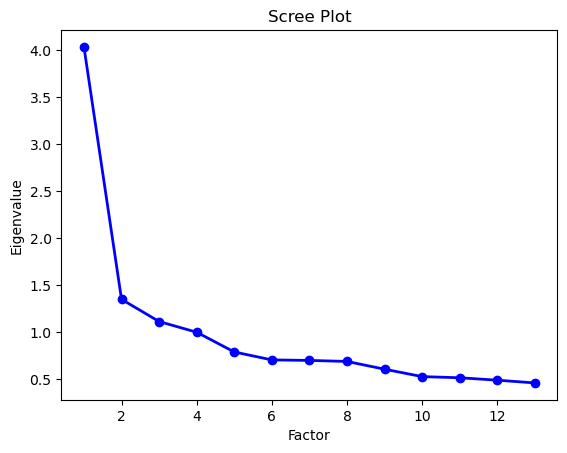

In [8]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [9]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

Luego de realizar el EFA, se determina que deben existir 3 factores por medio del método del codo. 

Para el primer factor, se consideran los sk 9, 10, 11, 12 y 13. 

Para el segundo, los sk: 1, 2, 3 y 4 

Para el último factor, los sk: 5, 6 y 8.

Notar que el sk7 no pertenece a ningun factor, por lo que se excluirá del analisis de aqui en adelante. Esto hará mas sentido cuando caractericemos cada factor, sin embargo se podia intuir este resultado al no tener similitudes claras con las otras preguntas, que en general engloban conceptos comunes


## Parte 3

In [10]:
fa = FactorAnalyzer(n_factors=3, rotation="varimax")
fa.fit(df_sk)

factor_scores = fa.transform(df_sk)
df_factors = pd.DataFrame(factor_scores, columns=["Factor1", "Factor2", "Factor3"])

df_factors["sexo"] = df["sexo"]
df_factors["area"] = df["area"]
df_factors["imce"] = df["imce"]
df_factors["act_fisica"] = df["act_fisica"]

c:\Users\joaqu\anaconda3\anaconda\envs\vsc_numpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\joaqu\anaconda3\anaconda\envs\vsc_numpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


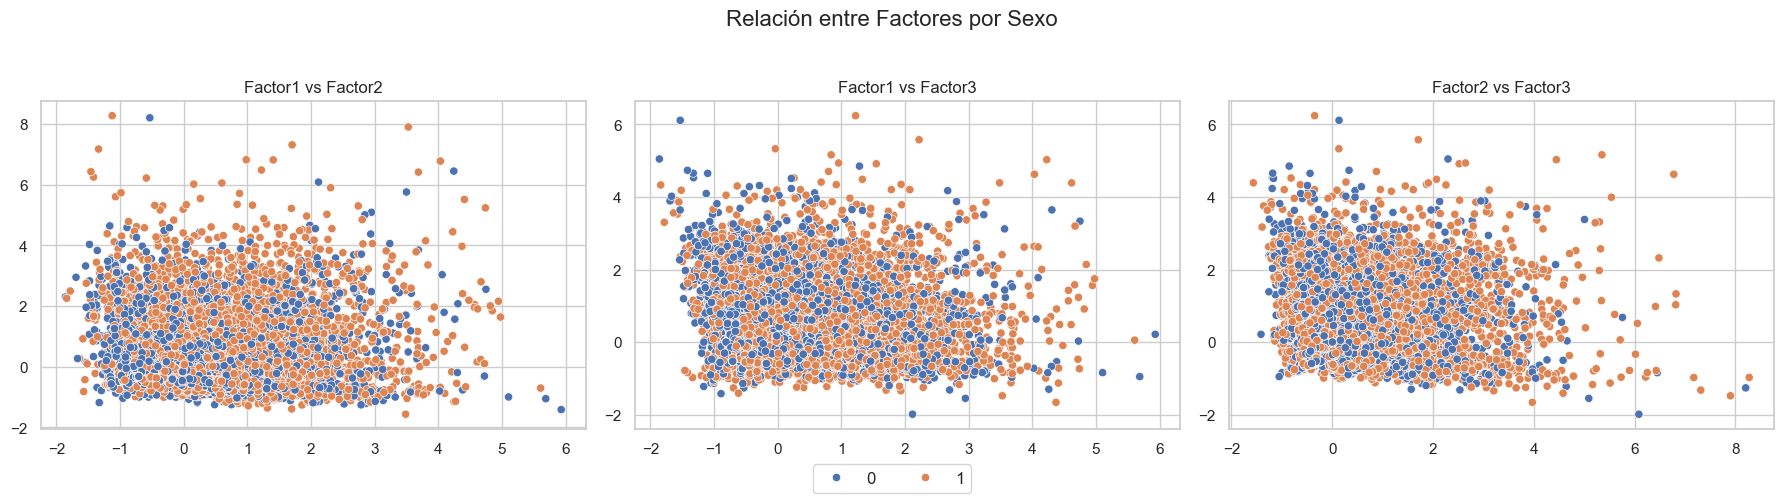

In [11]:
# Estilo general
sns.set(style="whitegrid")

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Factor1 vs Factor2
sns.scatterplot(data=df_factors, x="Factor1", y="Factor2", hue="sexo", ax=axes[0])
axes[0].set_title("Factor1 vs Factor2")

# Gráfico 2: Factor1 vs Factor3
sns.scatterplot(data=df_factors, x="Factor1", y="Factor3", hue="sexo", ax=axes[1])
axes[1].set_title("Factor1 vs Factor3")

# Gráfico 3: Factor2 vs Factor3
sns.scatterplot(data=df_factors, x="Factor2", y="Factor3", hue="sexo", ax=axes[2])
axes[2].set_title("Factor2 vs Factor3")

# Títulos y organización
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

# Acomodar leyenda y evitar que se repita en cada gráfico
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=12)
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.suptitle("Relación entre Factores por Sexo", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # deja espacio para el título y leyenda
plt.show()

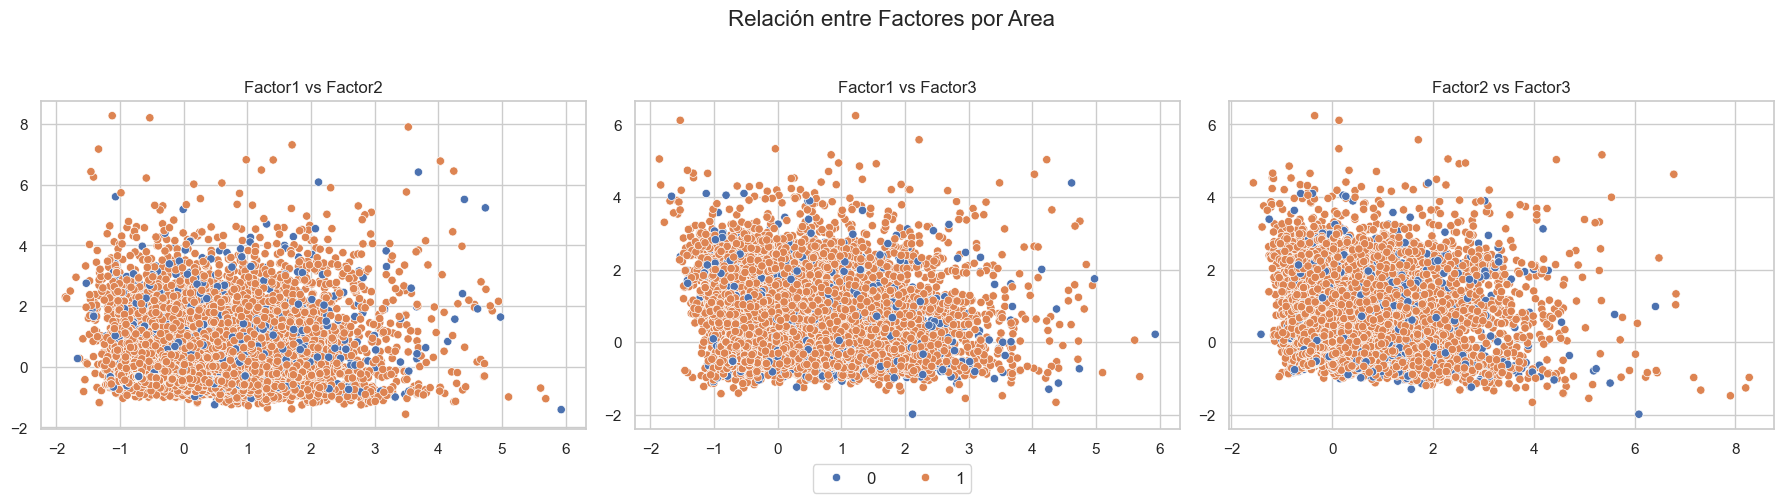

In [12]:
# Estilo general
sns.set(style="whitegrid")

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Factor1 vs Factor2
sns.scatterplot(data=df_factors, x="Factor1", y="Factor2", hue="area", ax=axes[0])
axes[0].set_title("Factor1 vs Factor2")

# Gráfico 2: Factor1 vs Factor3
sns.scatterplot(data=df_factors, x="Factor1", y="Factor3", hue="area", ax=axes[1])
axes[1].set_title("Factor1 vs Factor3")

# Gráfico 3: Factor2 vs Factor3
sns.scatterplot(data=df_factors, x="Factor2", y="Factor3", hue="area", ax=axes[2])
axes[2].set_title("Factor2 vs Factor3")

# Títulos y organización
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

# Acomodar leyenda y evitar que se repita en cada gráfico
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=12)
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.suptitle("Relación entre Factores por Area", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # deja espacio para el título y leyenda
plt.show()

C:\Users\joaqu\AppData\Local\Temp\ipykernel_24604\3054871691.py:9: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(data=df_factors, x="Factor1", y="Factor2", hue="act_fisica", ax=axes[0],  palette=sns.color_palette())
C:\Users\joaqu\AppData\Local\Temp\ipykernel_24604\3054871691.py:13: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(data=df_factors, x="Factor1", y="Factor3", hue="act_fisica", ax=axes[1],  palette=sns.color_palette())
C:\Users\joaqu\AppData\Local\Temp\ipykernel_24604\3054871691.py:17: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(data=df_factors, x="Factor2", y="Factor3", hue="act_fisica", ax=axes[2], palette=sns.color_palette())


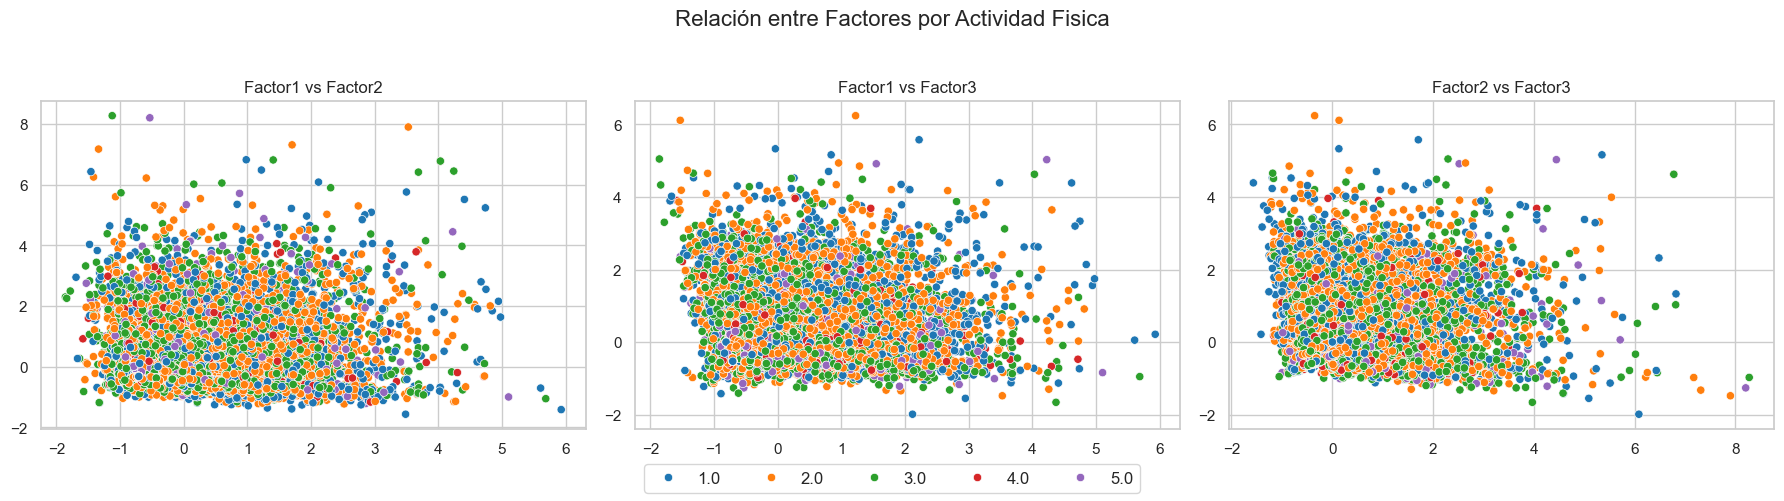

In [13]:
# Estilo general
sns.set(style="whitegrid")
sns.set_palette("tab10")

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Factor1 vs Factor2
sns.scatterplot(data=df_factors, x="Factor1", y="Factor2", hue="act_fisica", ax=axes[0],  palette=sns.color_palette())
axes[0].set_title("Factor1 vs Factor2")

# Gráfico 2: Factor1 vs Factor3
sns.scatterplot(data=df_factors, x="Factor1", y="Factor3", hue="act_fisica", ax=axes[1],  palette=sns.color_palette())
axes[1].set_title("Factor1 vs Factor3")

# Gráfico 3: Factor2 vs Factor3
sns.scatterplot(data=df_factors, x="Factor2", y="Factor3", hue="act_fisica", ax=axes[2], palette=sns.color_palette())
axes[2].set_title("Factor2 vs Factor3")

# Títulos y organización
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

# Acomodar leyenda y evitar que se repita en cada gráfico
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=12)
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.suptitle("Relación entre Factores por Actividad Fisica", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # deja espacio para el título y leyenda
plt.show()

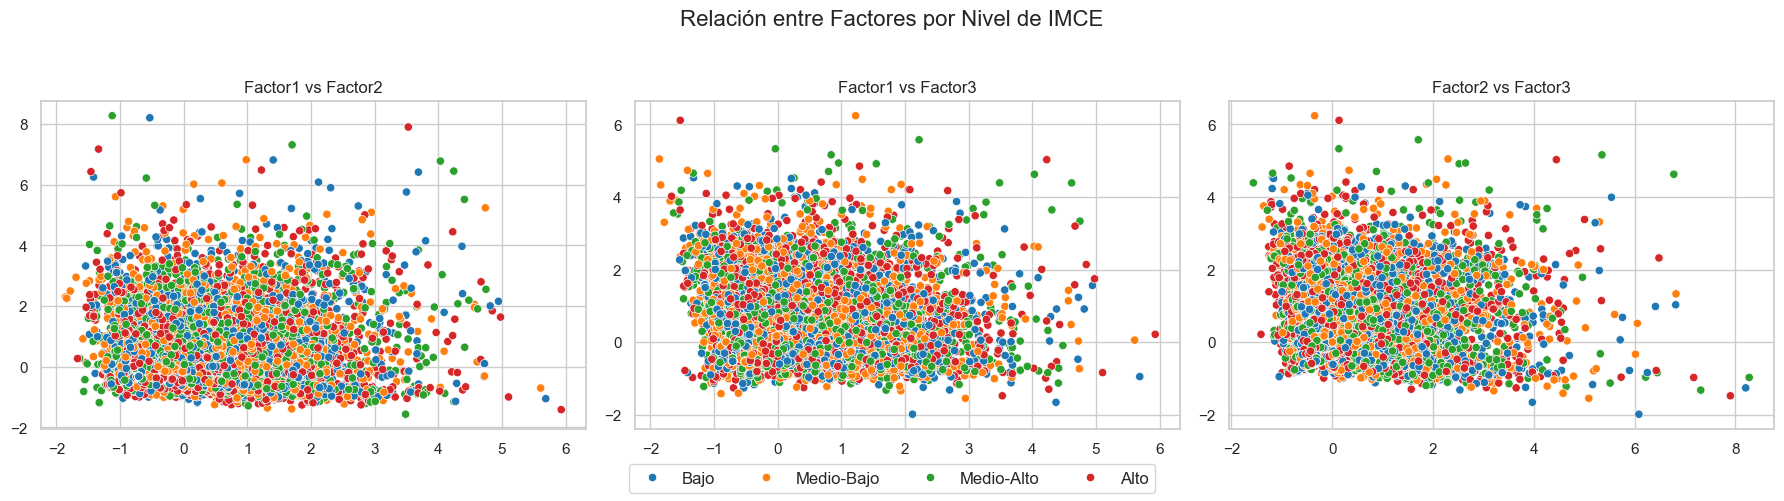

In [44]:
# Agrupar IMCE en 4 categorías (cuartiles)
df_factors["imce_cat"] = pd.qcut(df_factors["imce"], q=4, labels=["Bajo", "Medio-Bajo", "Medio-Alto", "Alto"])

# Estilo general
sns.set(style="whitegrid")
sns.set_palette("tab10")

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Factor1 vs Factor2
sns.scatterplot(data=df_factors, x="Factor1", y="Factor2", hue="imce_cat", ax=axes[0])
axes[0].set_title("Factor1 vs Factor2")

# Gráfico 2: Factor1 vs Factor3
sns.scatterplot(data=df_factors, x="Factor1", y="Factor3", hue="imce_cat", ax=axes[1])
axes[1].set_title("Factor1 vs Factor3")

# Gráfico 3: Factor2 vs Factor3
sns.scatterplot(data=df_factors, x="Factor2", y="Factor3", hue="imce_cat", ax=axes[2])
axes[2].set_title("Factor2 vs Factor3")

# Títulos y organización
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

# Leyenda única centrada abajo
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12)
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.suptitle("Relación entre Factores por Nivel de IMCE", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


Se puede apreciar como no hay diferencias entre la distribución de los factores con alguna medida en particular para ningun caso, lo cual hace sentido, ya que estas variables (actividad fisica, area, sexo e imce) no formaron parte explícita de la creación de los factores

## Parte 4

In [14]:
mod = """
# measurement model
f1 =~ sk9 + sk10 + sk11 + sk12 + sk13
f2 =~ sk1 + sk2 + sk3 + sk4
f3 =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(df_sk)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.091 0.049 0.057 0.161 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [15]:
model.inspect()


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,sk9,~,f1,1.000000,-,-,-
1,sk10,~,f1,1.348296,0.01854,72.725071,0.0
2,sk11,~,f1,1.247906,0.014736,84.684717,0.0
3,sk12,~,f1,1.097330,0.015523,70.692694,0.0
4,sk13,~,f1,1.273586,0.018913,67.339241,0.0
5,sk1,~,f2,1.000000,-,-,-
6,sk2,~,f2,1.876642,0.023793,78.87212,0.0
7,sk3,~,f2,1.646084,0.021121,77.934883,0.0
8,sk4,~,f2,1.845637,0.022169,83.253688,0.0
9,sk5,~,f3,1.000000,-,-,-


De acuerdo con los resultados de la parte 2, se proponen tres factores descritos a continuación:

Curiosidad (Factor 1): Este factor describiría el interés del niño por comprender, explorar y relacionarse con el mundo que lo rodea. Explica su disposición a aprender e investigar, junto con conseguir nuevas experiencias asociadas a conceptos, objetos o su entorno. Consideraría las variables sk9 (1.00) usado como referencia, sk10 (1.35), sk11 (1.25), sk12 (1.10) y sk13 (1.27). Entre paréntesis se encuentra la pertenencia de cada variable al factor, valores más que razonables.

Lado Emocional (Factor 2): Este factor evalúa la capacidad del niño para expresar sus emociones y sentimientos de manera efectiva, tanto verbal como no verbalmente. Refleja el desarrollo de la inteligencia emocional, incluyendo la vinculación afectiva con otros y la habilidad para comunicar sus estados de ánimo. Consideraría las variables sk1, sk2, sk3 y sk4. En este factor todas las variables aportan valores superiores a 1.64 en relación a a pregunta base sk1.

Relación entre pares (Factor 3): Este factor evalúa cómo el infante se relaciona con sus compañeros. Refleja aspectos como la disposición a compartir, la participación en juegos grupales y la interacción cooperativa, información relevante para el desarrollo en la infancia. Se consideran las variables sk5 (1.00), sk6 (1.02) y sk8 (1.16), con unas cargas de magnitud consistente que respaldan su inclusión en el factor.

In [16]:
mx = (model.inspect('mx'))  # devuelve todos los matrices internas
psi = mx['Psi']

std = (np.diag(psi))**0.5
cor = psi / np.outer(std, std)

print(cor)

          f1        f2        f3
f1  1.000000  0.595708  0.583238
f2  0.595708  1.000000  0.647256
f3  0.583238  0.647256  1.000000


La correlación entre factores se ve en la matriz calculada, donde vemos que todas se mueven entre el 58% y el 64%

## Parte 5

In [17]:
import warnings

warnings.filterwarnings("ignore")

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.77s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.42s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.86s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:19<00:00, 19.70s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:21<00:00, 21.66s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


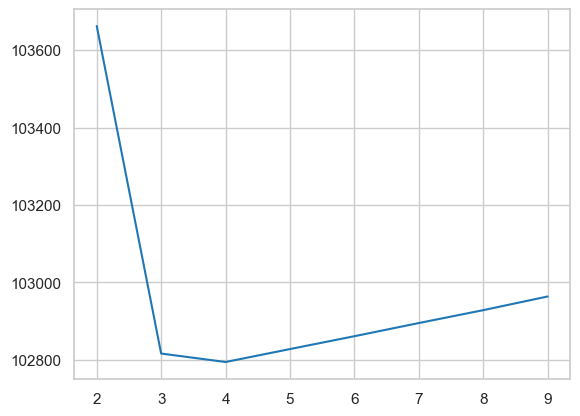

In [18]:
df_cluster = df[["imce"]]

K = range(2, 10)
fits = []
BIC = []

for k in K:
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=0).fit(df_cluster)
    fits.append(model)
    BIC.append(model.sabic(df_cluster))


sns.lineplot(x = K, y = BIC)    
plt.show()

In [19]:
df_cluster = df[["imce"]]

model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

model.fit(df_cluster)
df["Clase"]=model.predict(df_cluster)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.61s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


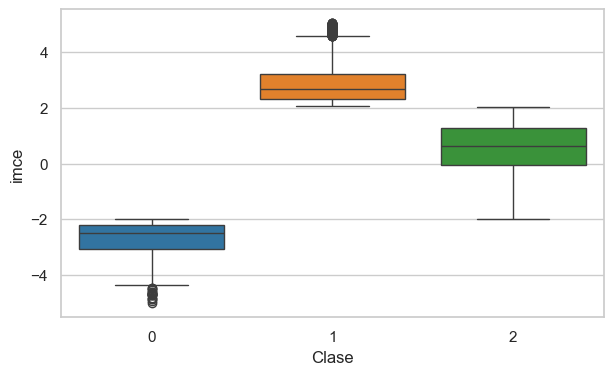

In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(df, x="Clase", y="imce", palette="tab10")
plt.show()

La primera gran diferencia entre clusters se encuentra lógicamente en los imce. El primer grupo (0) claramente encapsuló a la gente con un imce muy bajo, asociado a la desnutrición. Por esto mismo también son el grupo menos numeroso. Por otro lado, el grupo 1 tiene al caso opuesto, la gente con sobre peso, que corresponden a un 27% de los datos. Finalmente el grupo 2 tiene al resto de la muestra que se mueve en valores del imce "deseados".

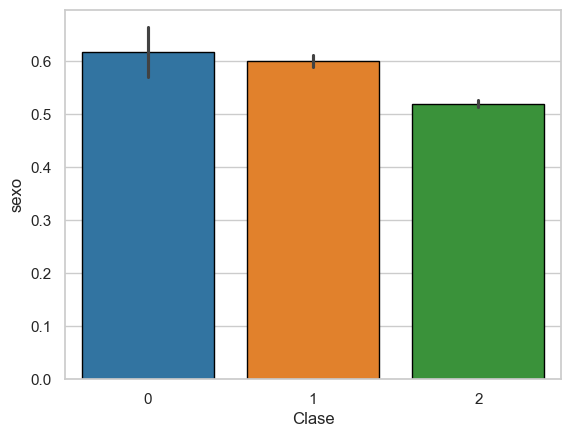

In [21]:
sns.barplot(df, x="Clase", y="sexo", palette="tab10", edgecolor="black")
plt.show()

También se encontraron diferencias leves en el género, habiendo más mujeres en los grupos de desnutrición seguido por el sobrepeso, aunque esta diferencia no es tan marcada, si existe, siendo de poco más de un 10% entre la clase 0 con la 2.

## Pregunta 6

In [22]:
df6 = df.copy()
df6["vive_madre"] = df6["vive_madre"].map({0 : 0,
                                           1 : 1,
                                           2 : 1})

df6["vive_padre"] = df6["vive_padre"].map({0 : 0,
                                            1 : 1,
                                            2 : 1})


df6["madre_work"] = df6["madre_work"].map({-1 : 0,
                                            0 : 0,
                                            1 : 1})
#df6["act_fisica"] = df6["act_fisica"].map({1 : 1,
 #                                        2 : 2,
 #                                        3 : 2,
  #                                       4 : 2,
   #                                      5 : 3})
df6["act_fisica_cont"] = df6["act_fisica"]
df6 = pd.get_dummies(df6, columns=["act_fisica", "madre_work"])
for col in df6.select_dtypes(include='bool').columns:
    df6[col] = df6[col].astype(int)

El imce se buscará explicar con las variables latentes descritas anteriormente, además, con la variable de educación del padre. Esta decisión se tomó ya que uno podría asociar los años de educación con el sueldo (A mayor educación uno espera que el sueldo sea mayor). Entendiendo como está configurada la familia chilena, es común que la principal fuente de ingresos de un hogar sea el padre, ingreso que en caso de ser alto, nos lleva al acceso a una mejor alimentación y otros servicios que deberia impactar en el imce. Además se incluyó el sexo de la persona, que vimos gráficamente que si se podria marcar la diferencia entre las diferentes segmentaciones del imce realizadas en la parte 5. La actividad física se espera que sea una variable de alto impacto, ya que en teoria, mayor ejercitación a la semana deberia ayudar a controlar el imce. Se decidió usar de forma continua y no categorica por motivos de especificación del modelo. Además, se incluye la binaria que nos indica 0 si la madre se encuentra en la casa (desempleada o como trabajo hogareño) y 1 si trabaja fuera de casa, ya que uno esperaría que una mayor presencia de la madre favoreceria a mejor alimentación y habitos en general que influyen en el imce. Finalmente está si la persona es de area urbana o rural, ya que el acceso a diferentes supermercados y otros servicios (Asociados a las escuelas tambien) varian de acuerdo a la zona en que se encuentre.

Por el lado de los factores, se propone que la edad y la educación de la madre impacten en el factor 1 (Curiosidad del infante), ya que una madre con mayor educación podría fomentar más el aprendizaje, la exploración y el interés por el entorno, mientras que la edad podría estar asociada a una mayor experiencia o madurez en actividades que estimulen la curiosidad, que la presencia de la madre y la presencia del padre describan el factor 2 (Lado emocional), donde uno podria argumentar (Lo cual no significa que sea cierto en todos los casos) que la presencia de los padres influye positivamente en el desarrollo psicoemocional de los niños, y el factor 3 (relacion con sus pares) con el factor 2, ya que esperamos que un niño que si demuestre emociones se relacione de mejor manera con sus compañeros y una binaria que indica si el niño realiza o no actividad física, ya que a esas edades la actividad de ese estilo suele ser en forma de deportes usualmente colaborativos, ya sea en la escuela o fuera de esta, por lo que si no realiza ninguna actividad deportiva esto podria impactar en su forma de relacionarse con ellos.

In [33]:
mod = """
# Structural model
imce ~ f1 + f2 + f3 + sexo + educp + act_fisica_cont + madre_work_1 + area
f1 ~ edad + educm 
f2 ~ vive_madre + vive_padre
f3 ~ act_fisica_1.0 + f2 

# measurement model
f1 =~ sk9 + sk10 + sk11 + sk12 + sk13
f2 =~ sk1 + sk2 + sk3 + sk4
f3 =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(df6)
print(out)
model.inspect()

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.608
Number of iterations: 49
Params: -0.021 -0.301 0.204 0.135 -0.017 -0.023 0.073 -0.133 0.015 -0.016 -0.050 -0.020 0.134 1.200 1.446 1.271 1.134 1.308 1.889 1.652 1.854 0.959 1.067 0.135 0.048 0.102 1.860 0.095 0.571 0.204 0.440 0.714 0.241 0.199 0.158 0.136 0.378 0.486 0.286


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,f1,~,edad,0.015483,0.000607,25.521401,0.0
1,f1,~,educm,-0.016048,0.000775,-20.705776,0.0
2,f2,~,vive_madre,-0.049769,0.009199,-5.410057,0.0
3,f2,~,vive_padre,-0.020179,0.003249,-6.21169,0.0
4,f3,~,act_fisica_1.0,0.134397,0.007269,18.489893,0.0
5,f3,~,f2,1.199885,0.018702,64.157251,0.0
6,imce,~,f1,-0.021253,0.024372,-0.872024,0.383195
7,imce,~,f2,-0.300827,0.064041,-4.69744,0.000003
8,imce,~,f3,0.203550,0.035092,5.800525,0.0
9,imce,~,sexo,0.134877,0.015915,8.474898,0.0


In [34]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,237,263,18054.6368,0.0,122144.500927,0.853812,0.852186,0.83597,0.852186,0.837774,0.050316,76.784036,400.435974,0.607982


El modelo no resultó ser el mejor en temas de ajuste, pero porque se priorizó una buena significancia en los parametros de las variables. Otras configuraciones del modelo disparaban CFI, TLI, pero añadiendo variables que no resultaban significativas.

Lo primero que llama la atención es que el factor asociado a la curiosidad no dio significativo. Realmente no es un resultado tan descabellado que este aspecto de la personalidad no impacte en el imce, que está más asociado a habitos de alimentación y deportes. Los otros factores si dieron significativos, y es que esto se puede explicar a que si se relacionan mas a comportamientos que impactan en dichos habitos como el juego en equipo y las reacciones a diferentes situaciones. La mayoria de suposiciones que se realizaron resultaron validadas por el modelo (Por ejemplo, una madre que trababaj fuera de casa impacta con un aumento en el imce, mientras que a mayor años de educación tenga el padre menos será el valor del imce). Tenemos además que, si el niño vive en un area urbana, su imce será menor en comparación al de un area rural, algo razonable considerando costumbres de ciertos pueblos donde uno puede esperar que se siguen priorizando costumbres de que mientras más se come es mejor, aunque se llegue a cantidadeds perjudiciales. 

Para los factores tenemos interpretaciones "dificiles" por temas de escala, ya que se construyeron con valores donde 1 representa algo positivo y 5 algo negativo, por lo tanto, el factor 2 (lado emocional), nos dice que si aumenta, osea, empeora lo que consideramos buen desempeño en el lado emocional, el imce disminuye. Un resultado de dificil interpretacion, aunque podría explicarse porque niños con menor expresión emocional podría asociarse a una alimentación más controlada por parte de los adultos. Por otro lado, el factor 3 (relaciones), nos dice que mientras aumente el factor (Osea, empeora su capacidad de relacionarse con compañeros), el imce aumenta, lo que si se condice con nuestra hipotesis inicial. Las variables con las que buscamos explicar los factores resultaron todas significativas y con los impactos esperados

In [41]:
model.predict_factors(df6)

,f1,f2,f3
0,-0.297780,-0.127157,-0.268337
1,-0.299622,-0.128150,-0.267661
2,-0.298379,-0.127480,-0.268117
3,-0.298676,-0.043585,-0.222632
4,0.753415,0.073269,0.389151
...,...,...,...
29691,0.147983,0.240378,0.464402
29692,0.312599,0.109045,-0.036981
29693,-0.112925,-0.128145,-0.267553
29694,-0.136958,-0.054987,0.316716


## Parte 7

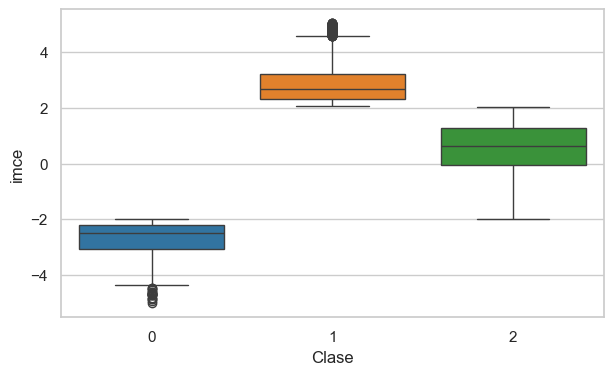

In [36]:
plt.figure(figsize=(7,4))
sns.boxplot(df6, x="Clase", y="imce", palette="tab10")
plt.show()

In [45]:
df_c0 = df6[df6["Clase"] == 0] #Desnutricion

out=model.fit(df_c0)
print(out)
model.inspect()

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.342
Number of iterations: 42
Params: -0.063 0.903 -0.406 -0.084 0.009 0.092 0.085 0.153 0.005 -0.024 -0.011 -0.052 0.069 1.661 1.154 1.239 0.908 1.175 2.471 2.094 2.602 1.086 1.288 0.186 0.029 0.069 0.464 0.079 0.645 0.197 0.343 0.754 0.228 0.202 0.151 0.164 0.407 0.540 0.311


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,f1,~,edad,0.004523,0.005759,0.785365,0.43224
1,f1,~,educm,-0.023574,0.007603,-3.10055,0.001932
2,f2,~,vive_madre,-0.010655,0.059933,-0.177783,0.858893
3,f2,~,vive_padre,-0.051784,0.021641,-2.392907,0.016715
4,f3,~,act_fisica_1.0,0.068707,0.05625,1.221454,0.221914
5,f3,~,f2,1.661065,0.217484,7.637653,0.0
6,imce,~,f1,-0.063172,0.088391,-0.714688,0.474802
7,imce,~,f2,0.902544,0.461233,1.956806,0.05037
8,imce,~,f3,-0.406059,0.213717,-1.899988,0.057435
9,imce,~,sexo,-0.084026,0.067875,-1.237941,0.215738


Para el caso de la desnutricion, tenemos que la unica variable que explican el imce de forma significativa es la actividad fisica. En este grupo nosotros buscamos subir el imce, no bajarlo, y tenemos que mayor actividad fisica mejora el valor, lo cual se puede asociar al desarrollo de masa muscular que es determinante en el calculo de imce (por el lado del peso).

In [38]:
df_c1 = df6[df6["Clase"] == 1] #Sobrepeso

out=model.fit(df_c1)
print(out)
model.inspect()

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.665
Number of iterations: 41
Params: -0.013 -0.164 0.133 0.178 -0.009 -0.002 -0.023 0.005 0.016 -0.015 -0.042 -0.031 0.163 1.149 1.438 1.256 1.161 1.377 1.803 1.458 1.622 0.906 1.002 0.142 0.058 0.125 0.444 0.095 0.604 0.214 0.470 0.744 0.243 0.218 0.162 0.144 0.405 0.545 0.278


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,f1,~,edad,0.016128,0.001307,12.341935,0.0
1,f1,~,educm,-0.015375,0.001666,-9.229928,0.0
2,f2,~,vive_madre,-0.042393,0.021287,-1.991494,0.046427
3,f2,~,vive_padre,-0.031036,0.007529,-4.122234,0.000038
4,f3,~,act_fisica_1.0,0.162896,0.016592,9.817791,0.0
5,f3,~,f2,1.149282,0.037171,30.919151,0.0
6,imce,~,f1,-0.013210,0.024444,-0.540428,0.588902
7,imce,~,f2,-0.163753,0.058155,-2.81583,0.004865
8,imce,~,f3,0.132601,0.032093,4.131813,0.000036
9,imce,~,sexo,0.177870,0.016412,10.838015,0.0


In [56]:
df_c1["act_fisica_cont"].describe()

count    6679.000000
mean        2.503369
std         1.033555
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: act_fisica_cont, dtype: float64

Notamos que para el grupo de sobrepeso, ni la actividad fisica, ni el area, ni la presencia de la madre en la casa se consideran relevantes. La razon de la actividad física podria estar en que estos infantes comparten patrones comunes en actividad fisica (Más de el 75% no realizan actividad física 3 veces a la semana) que no permiten marcar diferencias, situacion que se repite con las otras dos variables.

In [ ]:
df_c2 = df6[df6["Clase"] == 2] #Deseado

out=model.fit(df_c2)
print(out)
model.inspect()

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.611
Number of iterations: 37
Params: -0.028 -0.060 0.015 -0.023 -0.009 -0.004 0.039 -0.058 0.015 -0.016 -0.053 -0.016 0.128 1.206 1.453 1.277 1.131 1.289 1.907 1.711 1.921 0.974 1.083 0.132 0.046 0.096 0.823 0.095 0.560 0.201 0.432 0.703 0.241 0.193 0.156 0.133 0.370 0.467 0.287


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,f1,~,edad,0.015496,0.000689,22.47667,0.0
1,f1,~,educm,-0.016059,0.00088,-18.242372,0.0
2,f2,~,vive_madre,-0.053025,0.010284,-5.15594,0.0
3,f2,~,vive_padre,-0.016248,0.003629,-4.477346,0.000008
4,f3,~,act_fisica_1.0,0.127765,0.008125,15.724446,0.0
5,f3,~,f2,1.205816,0.021682,55.614078,0.0
6,imce,~,f1,-0.028446,0.018789,-1.514003,0.130025
7,imce,~,f2,-0.060184,0.050281,-1.196966,0.23132
8,imce,~,f3,0.015362,0.027635,0.555896,0.578282
9,imce,~,sexo,-0.023113,0.012127,-1.905867,0.056667


En el caso deseado curiosamente ningun factor resultó significativo, lo que nos está diciendo que la relevancia la tienen otras variables, especificamente la educacion del padre y la presencia de la madre en la casa. Ambas las asociamos a temas de habitos, control parental y temas alimenticios, que al parecer para este grupo son lo más relevante, por sobre la actividad fisica que uno esperaria esté en los esperado / normal para un niño de dicha edad

En general podemos ver que el modelo se desempeña peor cuando se ajusta con los segmentos por separado, pero esto nos entrega información de que es más relevante para cada grupo, lo cual tambien es util para el analisis.